In [ ]:
# Q1. Write a python program to implement XOR gate using a multi layer perceptron learning rule.


import numpy as np

X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=float)

y = np.array([
    [0],
    [1],
    [1],
    [0]
], dtype=float)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def sigmoid_derivative(x):
    return x * (1 - x)

np.random.seed(42)

input_neurons = 2
hidden_neurons = 4
output_neurons = 1


W1 = np.random.uniform(
    -1, 1,
    (input_neurons, hidden_neurons)
)

b1 = np.zeros(
    (1, hidden_neurons)
)


W2 = np.random.uniform(
    -1, 1,
    (hidden_neurons, output_neurons)
)

b2 = np.zeros(
    (1, output_neurons)
)

initial_W1 = W1.copy()
initial_W2 = W2.copy()

learning_rate = 0.5


for _ in range(10000):

    hidden_input = np.dot(X, W1) + b1

    hidden_output = sigmoid(
        hidden_input
    )


    output_input = np.dot(
        hidden_output,
        W2
    ) + b2

    predicted_output = sigmoid(
        output_input
    )

    error = y - predicted_output

    output_delta = (
        error *
        sigmoid_derivative(predicted_output)
    )


    hidden_error = np.dot(
        output_delta,
        W2.T
    )


    hidden_delta = (
        hidden_error *
        sigmoid_derivative(hidden_output)
    )

    W2 += (
        np.dot(
            hidden_output.T,
            output_delta
        )
        * learning_rate
    )

    b2 += (
        np.sum(
            output_delta,
            axis=0,
            keepdims=True
        )
        * learning_rate
    )
    W1 += (
        np.dot(
            X.T,
            hidden_delta
        )
        * learning_rate
    )

    b1 += (
        np.sum(
            hidden_delta,
            axis=0,
            keepdims=True
        )
        * learning_rate
    )

hidden_output = sigmoid(
    np.dot(X, W1) + b1
)


predicted_output = sigmoid(
    np.dot(hidden_output, W2) + b2
)

print("Initial Hidden Layer Weights:")
print(initial_W1)

print("\nFinal Updated Hidden Layer Weights:")
print(W1)


print("\nInitial Output Layer Weights:")
print(initial_W2)

print("\nFinal Updated Output Layer Weights:")
print(W2)

print("\n====================================")
print("XOR GATE RESULTS")
print("====================================")


correct_predictions = 0


for i in range(len(X)):

    result = (
        1
        if predicted_output[i][0] >= 0.5
        else 0
    )


    print(
        f"Input: {X[i].astype(int)} "
        f"Expected: {int(y[i][0])} "
        f"Predicted: {result}"
    )


    if result == int(y[i][0]):
        correct_predictions += 1


accuracy = (
    correct_predictions /
    len(X)
) * 100


print("\nAccuracy:", accuracy, "%")

Initial Hidden Layer Weights:
[[-0.25091976  0.90142861  0.46398788  0.19731697]
 [-0.68796272 -0.68801096 -0.88383278  0.73235229]]

Final Updated Hidden Layer Weights:
[[-0.40202049  4.60779894  6.37090183  3.82832237]
 [-1.20298037 -6.26244632 -4.77443726  3.84663039]]

Initial Output Layer Weights:
[[ 0.20223002]
 [ 0.41614516]
 [-0.95883101]
 [ 0.9398197 ]]

Final Updated Output Layer Weights:
[[ 1.5059499 ]
 [ 8.92519656]
 [-9.08595643]
 [ 4.44147084]]

XOR GATE RESULTS
Input: [0 0] Expected: 0 Predicted: 0
Input: [0 1] Expected: 1 Predicted: 1
Input: [1 0] Expected: 1 Predicted: 1
Input: [1 1] Expected: 0 Predicted: 0

Accuracy: 100.0 %


In [1]:
# Q2. Implement a Multi layer perceptron using a tensorflow library and calculate the accuracy of the model on the testing data. (Use MNIST dataset).
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow Version:", tf.__version__)

(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape :", X_test.shape)

X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

model.summary()

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("\n====================================")
print("MNIST TESTING RESULTS")
print("====================================")
print("Test Loss     :", test_loss)
print("Test Accuracy :", test_accuracy)

predictions = model.predict(
    X_test[:1],
    verbose=0
)

predicted_digit = np.argmax(predictions[0])

print("\nPrediction")
print("-------------------")
print("Actual Digit    :", y_test[0])
print("Predicted Digit :", predicted_digit)

plt.figure(figsize=(4, 4))

plt.imshow(
    X_test[0],
    cmap="gray"
)

plt.title(
    f"Actual: {y_test[0]}\nPredicted: {predicted_digit}"
)

plt.axis("off")

plt.show()

ModuleNotFoundError: No module named 'tensorflow'

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9242 - loss: 0.2594 - val_accuracy: 0.9672 - val_loss: 0.1095
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9653 - loss: 0.1115 - val_accuracy: 0.9747 - val_loss: 0.0849
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9767 - loss: 0.0752 - val_accuracy: 0.9740 - val_loss: 0.0870
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9815 - loss: 0.0586 - val_accuracy: 0.9772 - val_loss: 0.0872
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9850 - loss: 0.0468 - val_accuracy: 0.9768 - val_loss: 0.0848
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9876 - loss: 0.0381 - val_accuracy: 0.9788 - val_loss: 0.0712
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9898 - loss: 0.0310 - val_accuracy: 0.9770 - val_loss: 0.0897
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9913 - loss: 0.0272 -

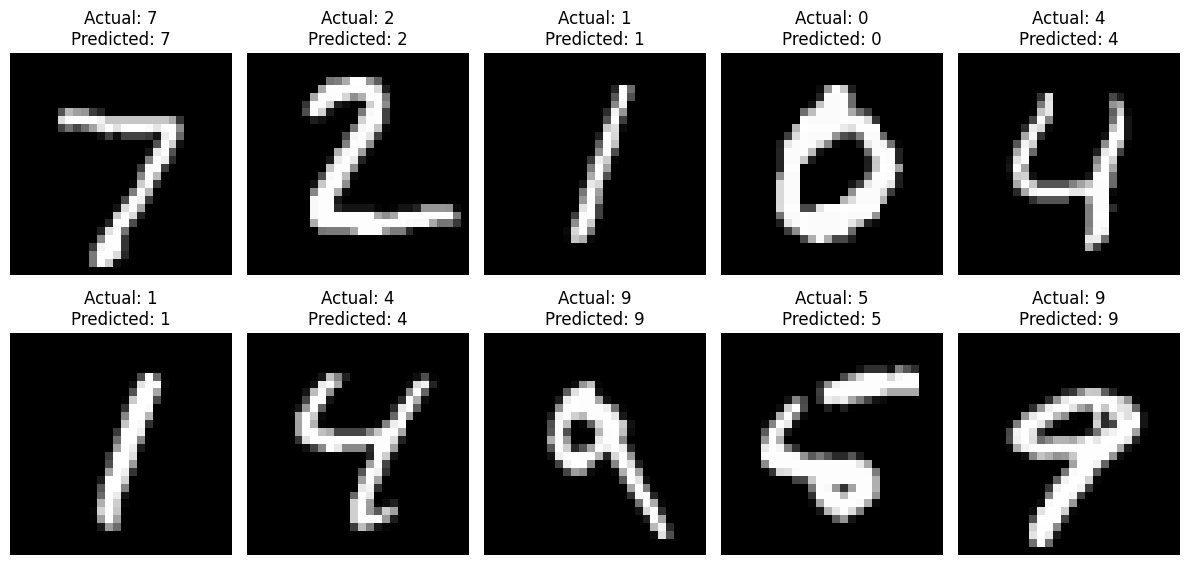

In [ ]:
# Q3. Write a python program to implement handwritten digit classification using ANN. (Use MNIST dataset).

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt


(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0



model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(
        128,
        activation="relu"
    ),

    tf.keras.layers.Dense(
        64,
        activation="relu"
    ),

    tf.keras.layers.Dense(
        10,
        activation="softmax"
    )
])



model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)



model.summary()



history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)



test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)


print("\n====================================")
print("HANDWRITTEN DIGIT CLASSIFICATION")
print("====================================")

print("Test Loss     :", test_loss)
print("Test Accuracy :", test_accuracy * 100, "%")



number_of_images = 10

predictions = model.predict(
    X_test[:number_of_images],
    verbose=0
)



print("\nPredictions")
print("-------------------")

for i in range(number_of_images):

    predicted_digit = np.argmax(predictions[i])

    print(
        f"Image {i + 1}: "
        f"Actual = {y_test[i]}, "
        f"Predicted = {predicted_digit}"
    )



plt.figure(figsize=(12, 6))

for i in range(number_of_images):

    predicted_digit = np.argmax(predictions[i])

    plt.subplot(2, 5, i + 1)

    plt.imshow(
        X_test[i],
        cmap="gray"
    )

    plt.title(
        f"Actual: {y_test[i]}\n"
        f"Predicted: {predicted_digit}"
    )

    plt.axis("off")


plt.tight_layout()
plt.show()

Dataset Loaded Successfully!

Dataset Shape:
(17000, 9)

First 5 Records:
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -114.31     34.19                15.0       5612.0          1283.0   
1    -114.47     34.40                19.0       7650.0          1901.0   
2    -114.56     33.69                17.0        720.0           174.0   
3    -114.57     33.64                14.0       1501.0           337.0   
4    -114.57     33.57                20.0       1454.0           326.0   

   population  households  median_income  median_house_value  
0      1015.0       472.0         1.4936             66900.0  
1      1129.0       463.0         1.8200             80100.0  
2       333.0       117.0         1.6509             85700.0  
3       515.0       226.0         3.1917             73400.0  
4       624.0       262.0         1.9250             65500.0  

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,521 (45.00 KB)

 Trainable params: 11,521 (45.00 KB)

 Non-trainable params: 0 (0.00 B)


Training ANN Model...
Epoch 1/50
383/383 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 49504739328.0000 - mae: 190357.3594 - val_loss: 27584841728.0000 - val_mae: 130909.6484
Epoch 2/50
383/383 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 13613349888.0000 - mae: 86096.9609 - val_loss: 11480824832.0000 - val_mae: 75104.0156
Epoch 3/50
383/383 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 8780359680.0000 - mae: 67777.0781 - val_loss: 8797579264.0000 - val_mae: 65875.8203
Epoch 4/50
383/383 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 7092085760.0000 - mae: 60794.2539 - val_loss: 7259828224.0000 - val_mae: 60934.5547
Epoch 5/50
383/383 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6065272832.0000 - mae: 56447.0898 - val_loss: 6283959296.0000 - val_mae: 57327.9062
Epoch 6/50
383/383 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5409068544.0000 - mae: 53499.7852 - val_loss: 5717285376.0000 - val_mae: 54882.0312
Epoch 7/50
383/383 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5013289984.0000 - mae: 51538.3828 - val_loss: 5


       ANN REGRESSION ANALYSIS RESULTS
Mean Squared Error      : 3867685196.0456486
Root Mean Squared Error : 62190.71631719358
Mean Absolute Error     : 44282.85107192096
R2 Score                : 0.7193027209069309

       ACTUAL VS PREDICTED VALUES
    Actual House Value  Predicted House Value
0             142700.0          137197.312500
1             500001.0          429429.375000
2              61800.0           86158.234375
3             162800.0          136734.937500
4              90600.0          152623.906250
5             232100.0          289053.593750
6             147800.0          144830.109375
7             133300.0          135872.875000
8             438500.0          371775.000000
9             187700.0          245984.375000
10             67500.0           88347.523438
11            179200.0          181143.812500
12            262500.0          323065.937500
13             57500.0           89269.398438
14             52900.0          165220.734375
15         

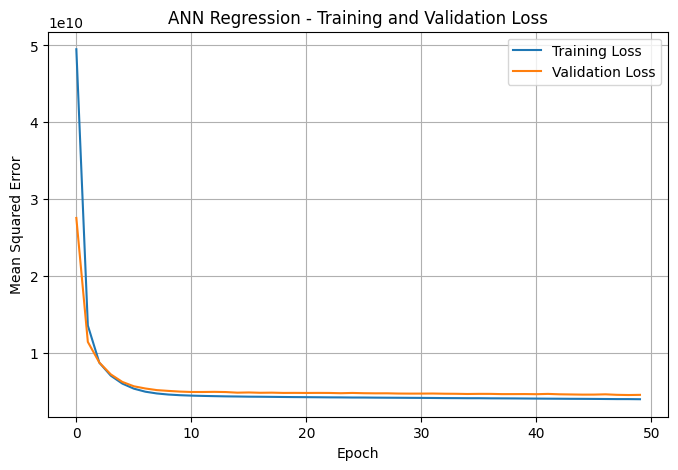

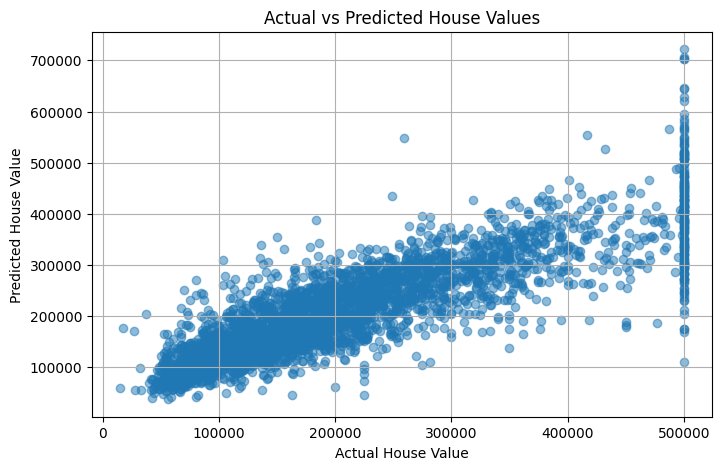


             SAMPLE PREDICTIONS
Actual: 142700.0 | Predicted: 137197.31
Actual: 500001.0 | Predicted: 429429.38
Actual: 61800.0 | Predicted: 86158.23
Actual: 162800.0 | Predicted: 136734.94
Actual: 90600.0 | Predicted: 152623.9

Regression Analysis Completed Successfully!


In [ ]:
# Q4. Write a python program to implement Regression Analysis using ANN. (Use california_housing_train.csv).


import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

file_name = "/content/sample_data/california_housing_train.csv"

data = pd.read_csv(file_name)

print("Dataset Loaded Successfully!")
print("\nDataset Shape:")
print(data.shape)

print("\nFirst 5 Records:")
print(data.head())

print("\nDataset Information:")
data.info()

print("\nMissing Values:")
print(data.isnull().sum())

data = data.dropna()

target_column = "median_house_value"

X = data.drop(columns=[target_column])
y = data[target_column]

print("\nInput Features:")
print(X.columns.tolist())

print("\nTarget Variable:")
print(target_column)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining Samples:", X_train.shape[0])
print("Testing Samples :", X_test.shape[0])

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(1, activation="linear")
])

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

model.summary()

history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

y_pred = model.predict(
    X_test,
    verbose=0
).flatten()

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n============================================")
print("ANN REGRESSION ANALYSIS RESULTS")
print("============================================")

print("Mean Squared Error      :", mse)
print("Root Mean Squared Error :", rmse)
print("Mean Absolute Error     :", mae)
print("R2 Score                :", r2)

comparison = pd.DataFrame({
    "Actual House Value": y_test.values[:20],
    "Predicted House Value": y_pred[:20]
})

print("\n============================================")
print("ACTUAL VS PREDICTED VALUES")
print("============================================")

print(comparison)

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("ANN Regression - Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Actual vs Predicted House Values")
plt.grid(True)
plt.show()

print("\n============================================")
print("SAMPLE PREDICTIONS")
print("============================================")

for i in range(5):
    print(
        "Actual:",
        y_test.iloc[i],
        "| Predicted:",
        round(y_pred[i], 2)
    )

print("\nRegression Analysis Completed Successfully!")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Data Shape: (60000, 28, 28)
Testing Data Shape : (10000, 28, 28)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)


EPOCH CALCULATION
Number of Training Samples : 60000
Batch Size                 : 32
Formula: Batches per Epoch = Training Samples / Batch Size
Calculation: 60000 / 32
Batches per Epoch: 1875
Number of Epochs: 10
Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8713 - loss: 0.5036 - val_accuracy: 0.9447 - val_loss: 0.1909
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9445 - loss: 0.1873 - val_accuracy: 0.9657 - val_loss: 0.1311
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9619 - loss: 0.1297 - val_accuracy: 0.9690 - val_loss: 0.1046
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.9719 - loss: 0.0970 - val_accuracy: 0.9705 - val_loss: 0.0938
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.9780 - loss: 0.0741 - val_accuracy: 0.9755 - val_loss: 0.0814
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9829 - loss: 0.0587 - val_accuracy: 0.9773 - val_loss: 0.0725
E


FEED FORWARD NEURAL NETWORK
Test Loss     : 0.07539048045873642
Test Accuracy : 97.65999913215637 %

Predictions:
----------------------------
Image 1: Actual = 7, Predicted = 7
Image 2: Actual = 2, Predicted = 2
Image 3: Actual = 1, Predicted = 1
Image 4: Actual = 0, Predicted = 0
Image 5: Actual = 4, Predicted = 4
Image 6: Actual = 1, Predicted = 1
Image 7: Actual = 4, Predicted = 4
Image 8: Actual = 9, Predicted = 9
Image 9: Actual = 5, Predicted = 5
Image 10: Actual = 9, Predicted = 9


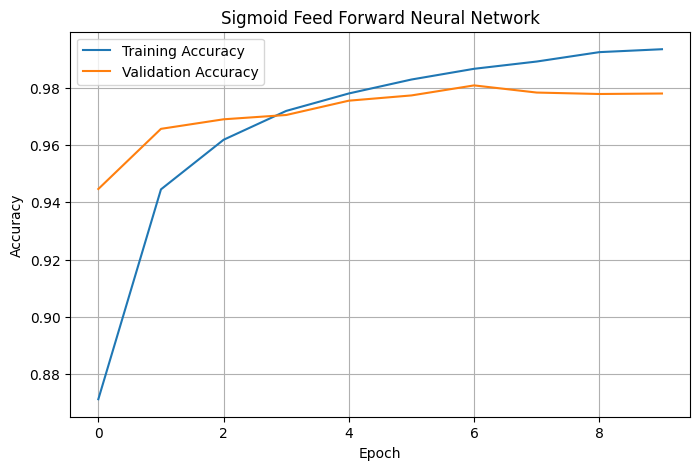

In [ ]:
# Q5. Write a python program to build a Feed forward Neural network using Sigmoid activation function. (Use MNIST dataset).


import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt



(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape :", X_test.shape)



X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0




model = tf.keras.Sequential([


    tf.keras.layers.Input(shape=(28, 28)),


    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(
        128,
        activation="sigmoid"
    ),


    tf.keras.layers.Dense(
        64,
        activation="sigmoid"
    ),


    tf.keras.layers.Dense(
        10,
        activation="softmax"
    )
])



model.summary()


model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


epochs = 10
batch_size = 32


number_of_training_samples = len(X_train)

batches_per_epoch = np.ceil(
    number_of_training_samples / batch_size
)


print("\n====================================")
print("EPOCH CALCULATION")
print("====================================")

print("Number of Training Samples :", number_of_training_samples)
print("Batch Size                 :", batch_size)

print(
    "Formula: Batches per Epoch = "
    "Training Samples / Batch Size"
)

print(
    "Calculation:",
    number_of_training_samples,
    "/",
    batch_size
)

print(
    "Batches per Epoch:",
    int(batches_per_epoch)
)

print("Number of Epochs:", epochs)



history = model.fit(
    X_train,
    y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.1,
    verbose=1
)




test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)


print("\n====================================")
print("FEED FORWARD NEURAL NETWORK")
print("====================================")

print("Test Loss     :", test_loss)
print("Test Accuracy :", test_accuracy * 100, "%")



predictions = model.predict(
    X_test[:10],
    verbose=0
)


print("\nPredictions:")
print("----------------------------")


for i in range(10):

    predicted_digit = np.argmax(predictions[i])

    print(
        f"Image {i + 1}: "
        f"Actual = {y_test[i]}, "
        f"Predicted = {predicted_digit}"
    )



plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Sigmoid Feed Forward Neural Network")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# Set B - Q1. Write a python program to implement XNOR gate using a multi layer perceptron learning rule.


import numpy as np



X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=float)



y = np.array([
    [1],
    [0],
    [0],
    [1]
], dtype=float)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def sigmoid_derivative(x):
    return x * (1 - x)


np.random.seed(42)

input_neurons = 2
hidden_neurons = 4
output_neurons = 1


W1 = np.random.uniform(
    -1, 1,
    (input_neurons, hidden_neurons)
)

b1 = np.zeros(
    (1, hidden_neurons)
)


W2 = np.random.uniform(
    -1, 1,
    (hidden_neurons, output_neurons)
)

b2 = np.zeros(
    (1, output_neurons)
)


initial_W1 = W1.copy()
initial_W2 = W2.copy()


learning_rate = 0.5


for _ in range(10000):

    hidden_input = np.dot(X, W1) + b1

    hidden_output = sigmoid(
        hidden_input
    )


    output_input = np.dot(
        hidden_output,
        W2
    ) + b2

    predicted_output = sigmoid(
        output_input
    )

    error = y - predicted_output


    output_delta = (
        error *
        sigmoid_derivative(predicted_output)
    )


    hidden_error = np.dot(
        output_delta,
        W2.T
    )


    hidden_delta = (
        hidden_error *
        sigmoid_derivative(hidden_output)
    )

    W2 += (
        np.dot(
            hidden_output.T,
            output_delta
        )
        * learning_rate
    )



    b2 += (
        np.sum(
            output_delta,
            axis=0,
            keepdims=True
        )
        * learning_rate
    )


    W1 += (
        np.dot(
            X.T,
            hidden_delta
        )
        * learning_rate
    )



    b1 += (
        np.sum(
            hidden_delta,
            axis=0,
            keepdims=True
        )
        * learning_rate
    )


hidden_output = sigmoid(
    np.dot(X, W1) + b1
)


predicted_output = sigmoid(
    np.dot(hidden_output, W2) + b2
)


print("Initial Hidden Layer Weights:")
print(initial_W1)


print("\nFinal Updated Hidden Layer Weights:")
print(W1)


print("\nInitial Output Layer Weights:")
print(initial_W2)


print("\nFinal Updated Output Layer Weights:")
print(W2)


print("\n====================================")
print("XNOR GATE RESULTS")
print("====================================")


correct_predictions = 0


for i in range(len(X)):

    result = (
        1
        if predicted_output[i][0] >= 0.5
        else 0
    )


    print(
        f"Input: {X[i].astype(int)} "
        f"Expected: {int(y[i][0])} "
        f"Predicted: {result}"
    )


    if result == int(y[i][0]):
        correct_predictions += 1

accuracy = (
    correct_predictions /
    len(X)
) * 100


print("\nAccuracy:", accuracy, "%")

Initial Hidden Layer Weights:
[[-0.25091976  0.90142861  0.46398788  0.19731697]
 [-0.68796272 -0.68801096 -0.88383278  0.73235229]]

Final Updated Hidden Layer Weights:
[[-2.57873909  6.37497422  5.30646327 -0.4237909 ]
 [-2.94493139 -5.29385843 -6.30875916  0.33815146]]

Initial Output Layer Weights:
[[ 0.20223002]
 [ 0.41614516]
 [-0.95883101]
 [ 0.9398197 ]]

Final Updated Output Layer Weights:
[[ 2.61492629]
 [ 8.95928929]
 [-9.52961557]
 [-1.42087167]]

XNOR GATE RESULTS
Input: [0 0] Expected: 1 Predicted: 1
Input: [0 1] Expected: 0 Predicted: 0
Input: [1 0] Expected: 0 Predicted: 0
Input: [1 1] Expected: 1 Predicted: 1

Accuracy: 100.0 %


Input Shape : (4, 2)
Output Shape: (4, 1)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                │ (None, 8)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65 (260.00 B)

 Trainable params: 65 (260.00 B)

 Non-trainable params: 0 (0.00 B)


EPOCH CALCULATION
Number of Training Samples : 4
Batch Size  : 4
Formula: Steps per Epoch = Training Samples / Batch Size
Calculation: 4 / 4
Steps per Epoch: 1
Number of Epochs: 1000



FEED FORWARD NEURAL NETWORK
Final Loss     : 0.05723836272954941
Final Accuracy : 100.0 %

Predictions:
----------------------------
Input = [0 0], Actual = 0, Predicted = 0
Input = [0 1], Actual = 1, Predicted = 1
Input = [1 0], Actual = 1, Predicted = 1
Input = [1 1], Actual = 0, Predicted = 0


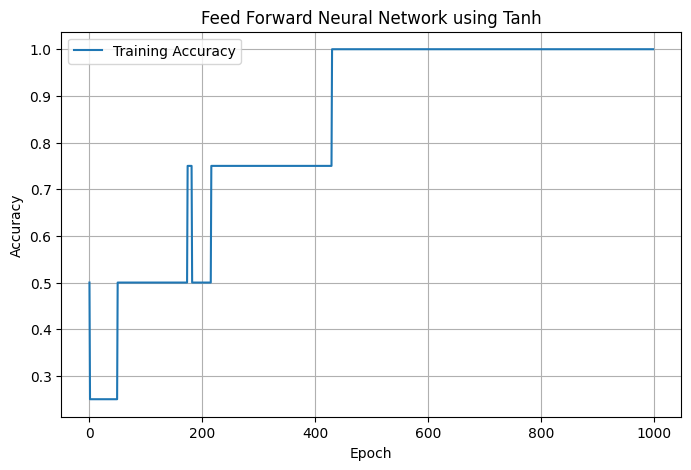

In [ ]:
# Set B - Q2. Write a python program to implement Feedforward neural network using Tanh activation function.

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt



X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=np.float32)

y = np.array([
    [0],
    [1],
    [1],
    [0]
], dtype=np.float32)


print("Input Shape :", X.shape)
print("Output Shape:", y.shape)



model = tf.keras.Sequential([


    tf.keras.layers.Input(shape=(2,)),


    tf.keras.layers.Dense(
        8,
        activation="tanh"
    ),


    tf.keras.layers.Dense(
        4,
        activation="tanh"
    ),


    tf.keras.layers.Dense(
        1,
        activation="sigmoid"
    )
])

model.summary()

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

epochs = 1000
batch_size = 4

number_of_training_samples = len(X)

steps_per_epoch = np.ceil(
    number_of_training_samples / batch_size
)


print("\n====================================")
print("EPOCH CALCULATION")
print("====================================")

print(
    "Number of Training Samples :",
    number_of_training_samples
)

print(
    "Batch Size  :",
    batch_size
)

print(
    "Formula: Steps per Epoch = "
    "Training Samples / Batch Size"
)

print(
    "Calculation:",
    number_of_training_samples,
    "/",
    batch_size
)

print(
    "Steps per Epoch:",
    int(steps_per_epoch)
)

print(
    "Number of Epochs:",
    epochs
)

history = model.fit(
    X,
    y,
    epochs=epochs,
    batch_size=batch_size,
    verbose=0
)

loss, accuracy = model.evaluate(
    X,
    y,
    verbose=0
)


print("\n====================================")
print("FEED FORWARD NEURAL NETWORK")
print("====================================")

print("Final Loss     :", loss)
print("Final Accuracy :", accuracy * 100, "%")




predictions = model.predict(
    X,
    verbose=0
)

predicted_output = (predictions >= 0.5).astype(int)


print("\nPredictions:")
print("----------------------------")


for i in range(len(X)):

    print(
        f"Input = {X[i].astype(int)}, "
        f"Actual = {int(y[i][0])}, "
        f"Predicted = {int(predicted_output[i][0])}"
    )


plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.title("Feed Forward Neural Network using Tanh")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()